In [40]:
import importlib
import src.ingestion
import src.preproc
import src.eda
import src.garch
importlib.reload(src.ingestion)
importlib.reload(src.preproc)
importlib.reload(src.eda)
importlib.reload(src.garch)
from src.ingestion import *
from src.preproc import *
from src.eda import *
from src.garch import *

### Data Loading and Preprocessing

In [19]:
download_assets()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

=== Asset Price Data Collection ===
Saved → dataset\BTC-USD.csv
Saved → dataset\ETH-USD.csv



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Saved → dataset\^GSPC.csv
Saved → dataset\^GSPTSE.csv
Saved → dataset\^HSI.csv
Saved → dataset\^BVSP.csv



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Saved → dataset\^AXJO.csv
Saved → dataset\^NSEI.csv
Saved → dataset\GC=F.csv
Saved → dataset\USDINR=X.csv
Saved → dataset\CAD=X.csv



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Saved → dataset\HKD=X.csv
Saved → dataset\BRL=X.csv
Saved → dataset\AUD=X.csv
=== Data Collection Complete ===


In [20]:
nan_summary = check_nan_across_files()
nan_summary.head()

=== NaN CHECK ACROSS ALL FILES ===

File: AUD=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BRL=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BTC-USD.csv
Shape: (2191, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: CAD=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: ETH-USD.csv
Shape: (2191, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: GC=F.csv
Shape: (1509, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: HKD=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: USDINR=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
-------------------------

,file,rows,cols,total_nans,nan_pct
0,AUD=X.csv,1561,7,0,0.0
1,BRL=X.csv,1561,7,0,0.0
2,BTC-USD.csv,2191,7,0,0.0
3,CAD=X.csv,1561,7,0,0.0
4,ETH-USD.csv,2191,7,0,0.0


In [21]:
calendar_summary = check_calendar_alignment()
calendar_summary.head()

=== CALENDAR ALIGNMENT CHECK ===

Global date range: 2020-01-01 → 2025-12-30
Total unique dates (union): 2191

Common dates across ALL assets: 1299
Overlap ratio: 0.5929

AUD=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------
BRL=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------
BTC-USD:
  available: 2191
  missing: 0 (0.00%)
----------------------------------------
CAD=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------

,ticker,available_dates,missing_dates,missing_pct
12,^HSI,1475,716,32.679142
13,^NSEI,1485,706,32.222729
9,^BVSP,1494,697,31.811958
11,^GSPTSE,1505,686,31.309904
10,^GSPC,1507,684,31.218622


In [22]:
keep_common_dates()

=== KEEPING ONLY COMMON DATES ACROSS ALL ASSETS ===

Common dates retained: 1299
AUD=X: 1561 → 1299 rows
BRL=X: 1561 → 1299 rows
BTC-USD: 2191 → 1299 rows
CAD=X: 1561 → 1299 rows
ETH-USD: 2191 → 1299 rows
GC=F: 1509 → 1299 rows
HKD=X: 1561 → 1299 rows
USDINR=X: 1561 → 1299 rows
^AXJO: 1518 → 1299 rows
^BVSP: 1494 → 1299 rows
^GSPC: 1507 → 1299 rows
^GSPTSE: 1505 → 1299 rows
^HSI: 1475 → 1299 rows
^NSEI: 1485 → 1299 rows

=== ALL FILES NOW PERFECTLY ALIGNED ===


In [23]:
convert_all_to_inr()

=== CONVERTING ALL ASSETS TO INR ===

Processing BTC-USD...
✔ Converted BTC-USD to INR
Processing ETH-USD...
✔ Converted ETH-USD to INR
Processing GC=F...
✔ Converted GC=F to INR
Processing ^AXJO...
✔ Converted ^AXJO to INR
Processing ^BVSP...
✔ Converted ^BVSP to INR
Processing ^GSPC...
✔ Converted ^GSPC to INR
Processing ^GSPTSE...
✔ Converted ^GSPTSE to INR
Processing ^HSI...
✔ Converted ^HSI to INR
Processing ^NSEI...
✔ Converted ^NSEI to INR

=== ALL FILES CONVERTED TO INR ===


### EDA

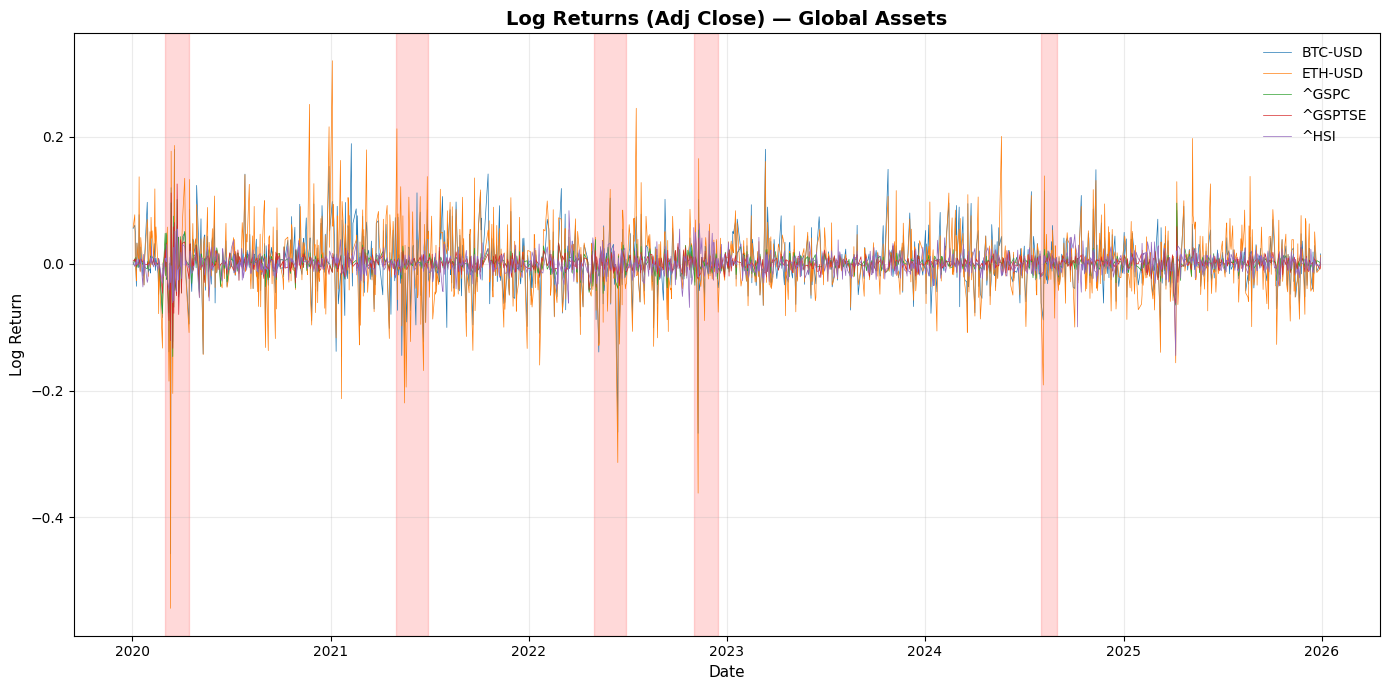

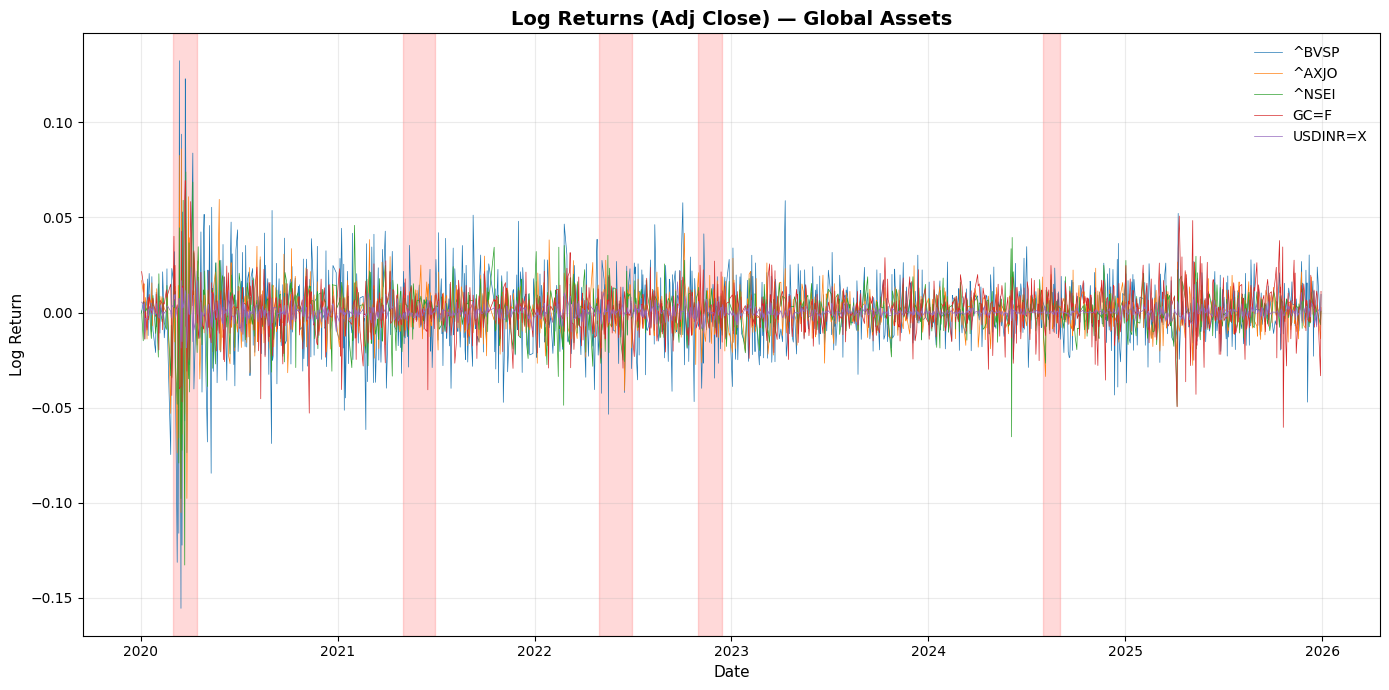

In [41]:
plot_global_log_returns(batch_size=5)

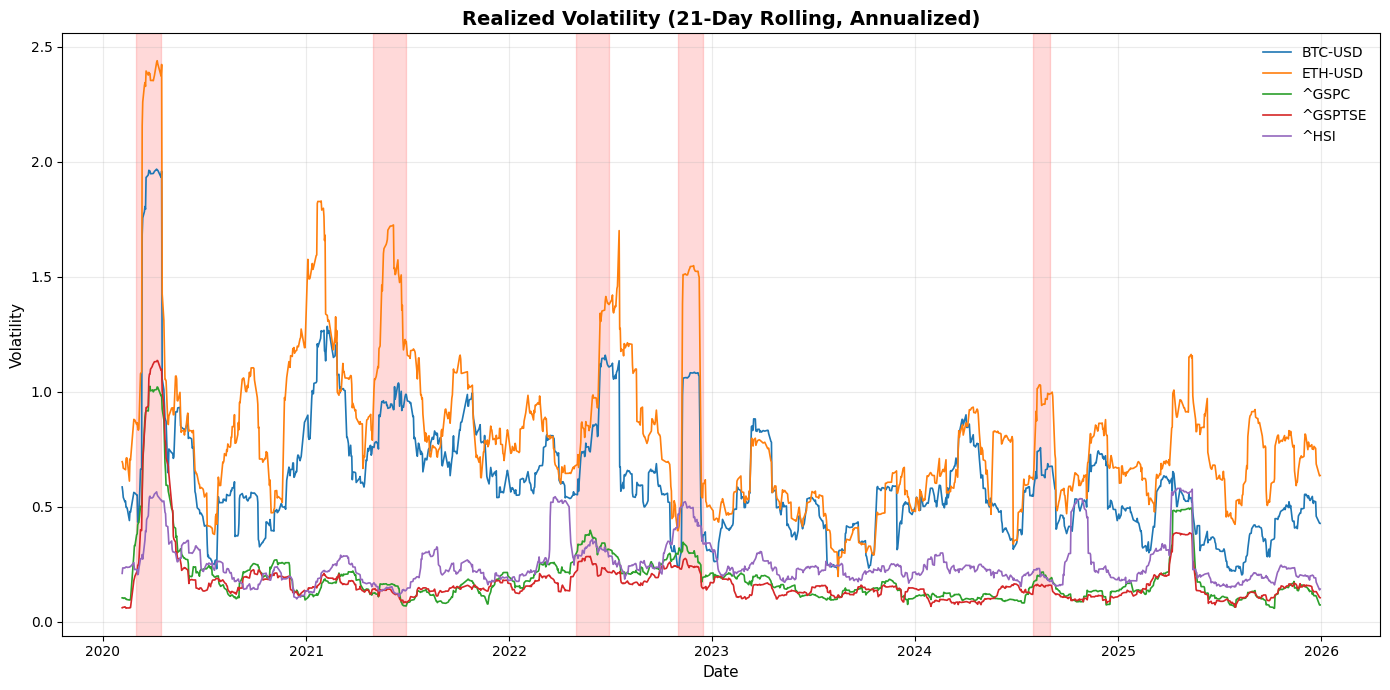

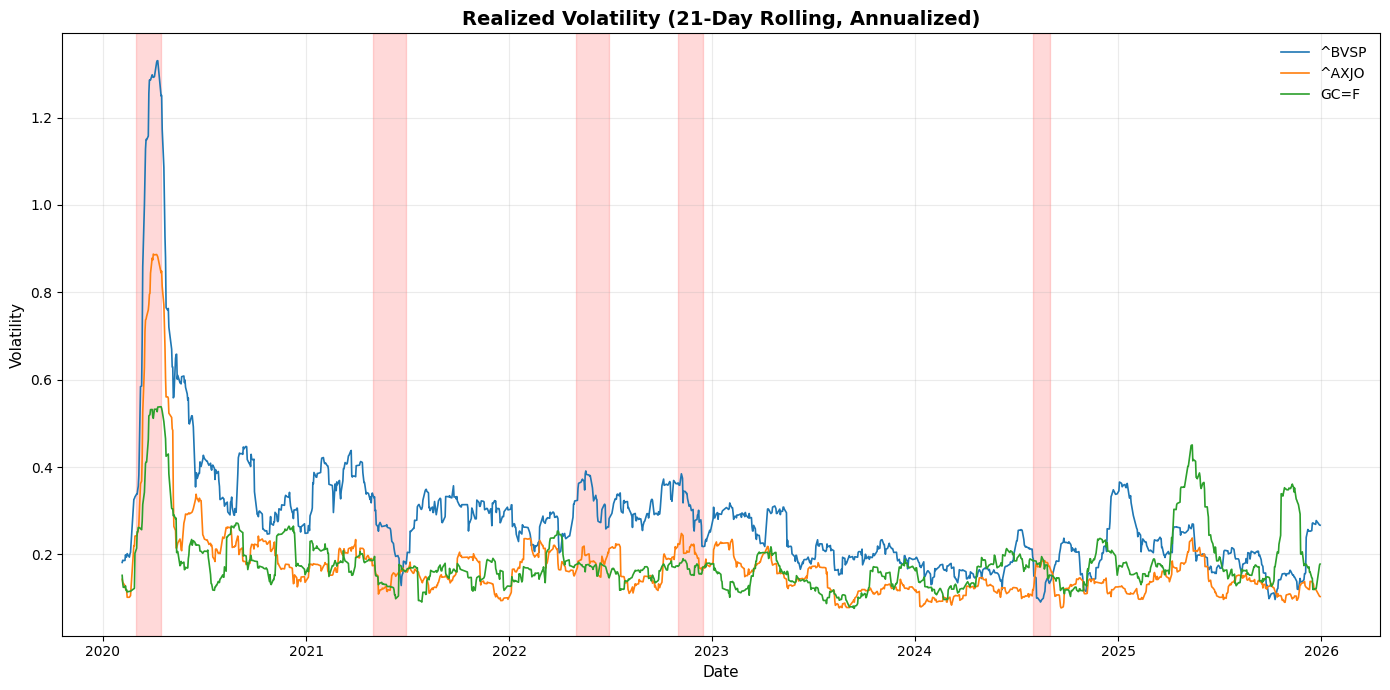

In [42]:
plot_realized_volatility(batch_size=5)

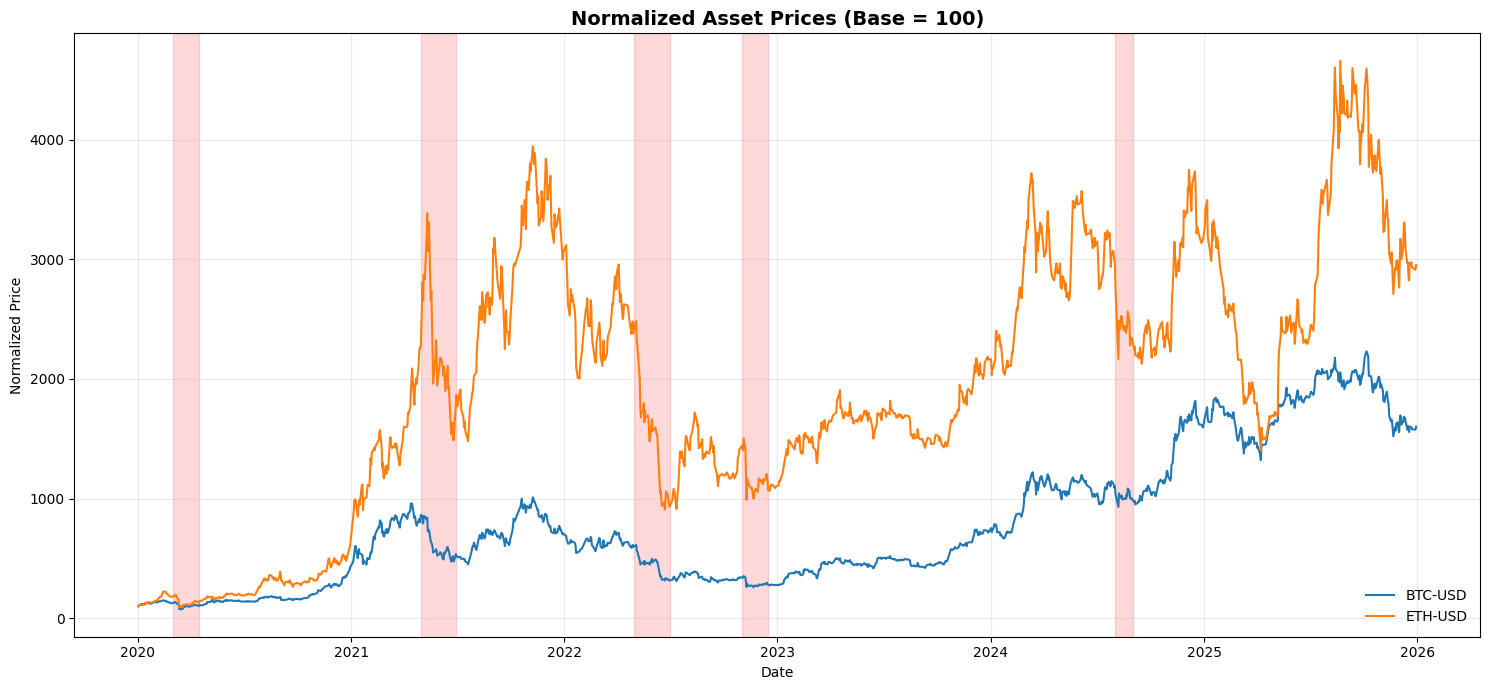

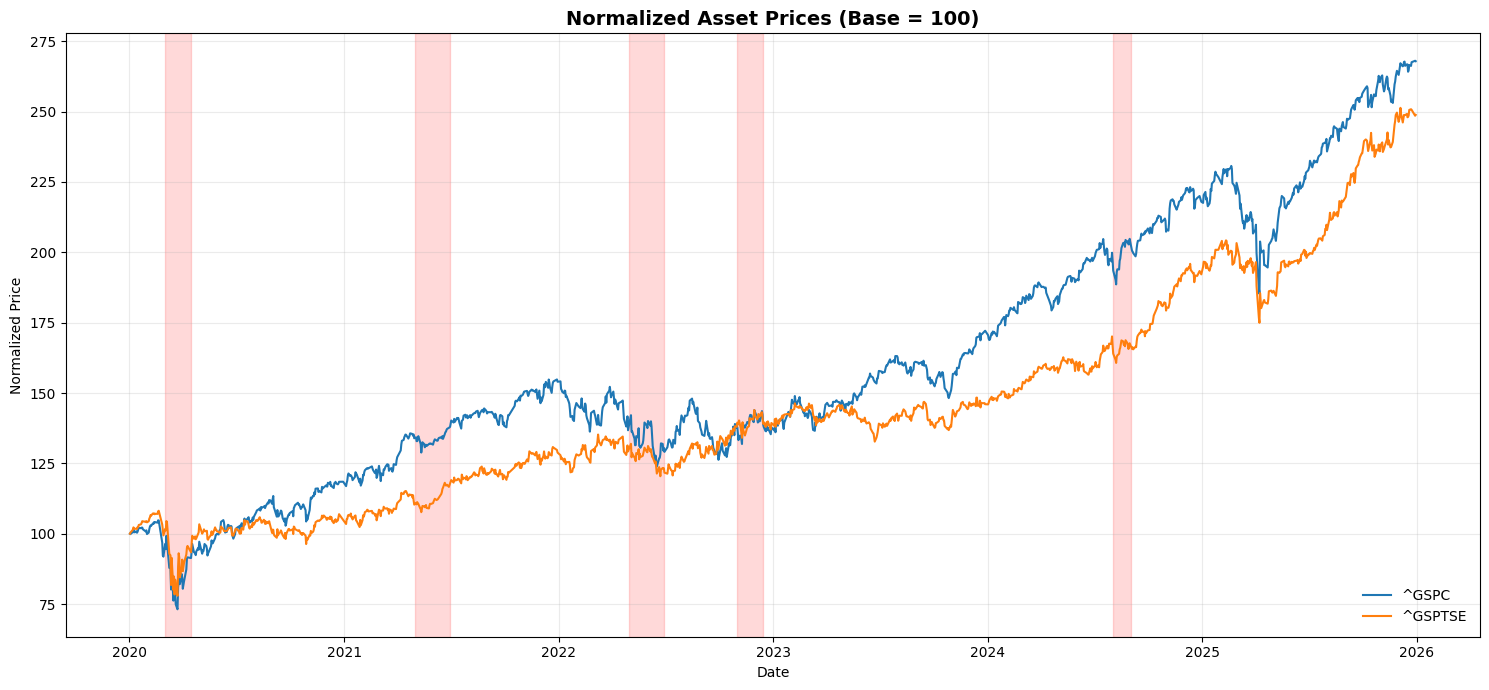

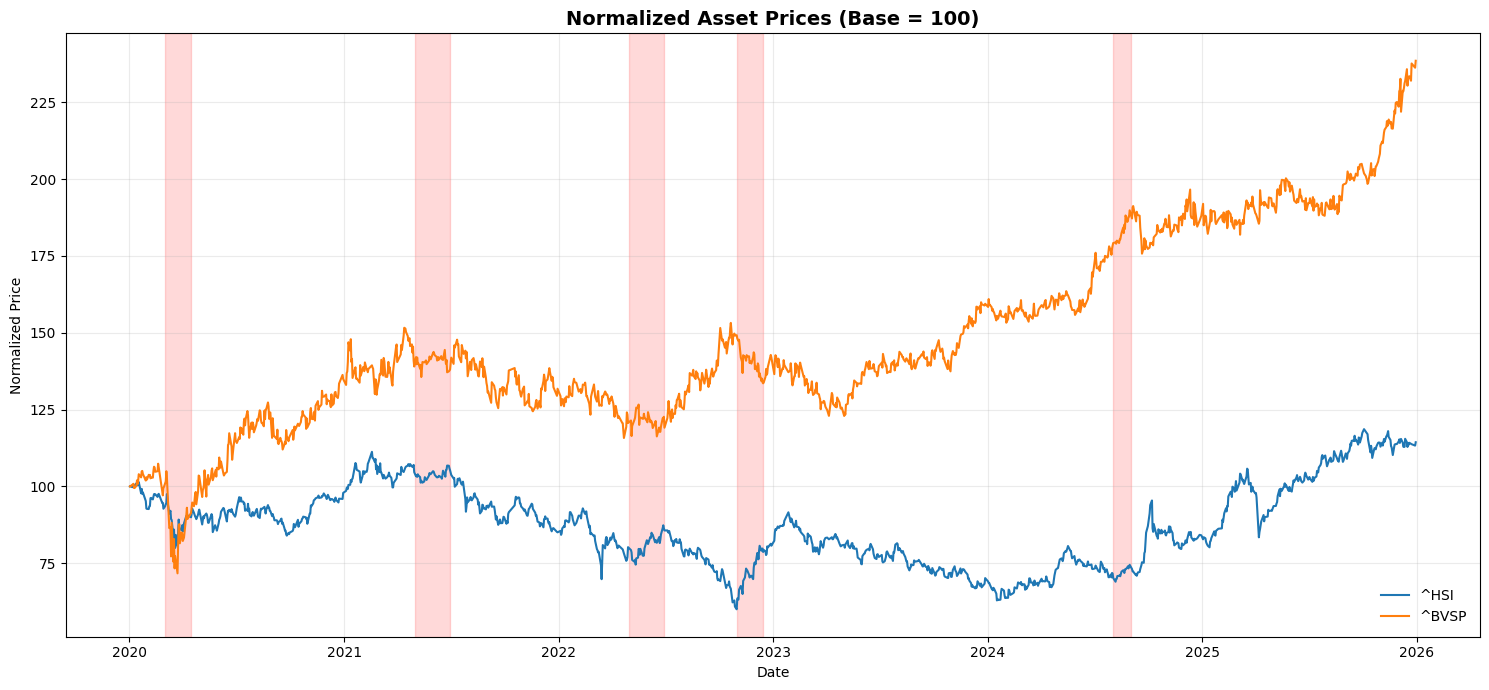

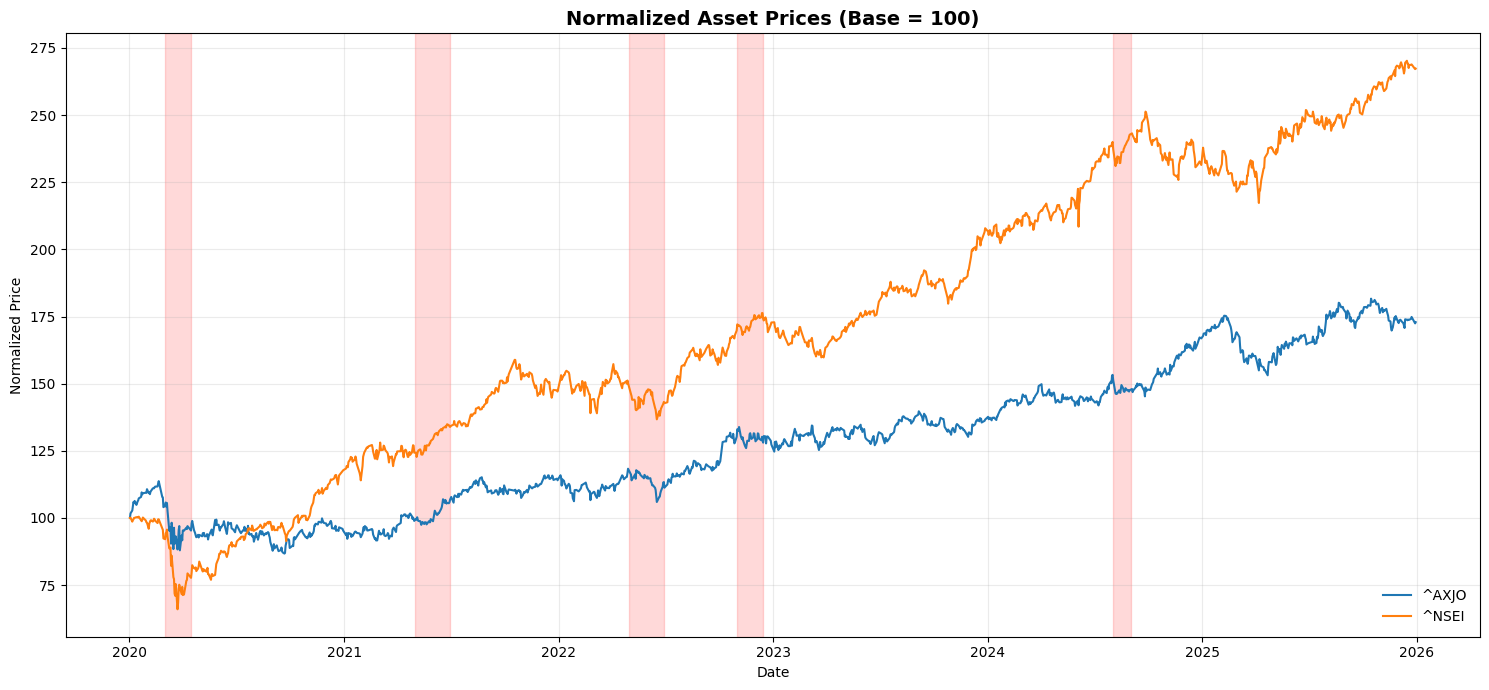

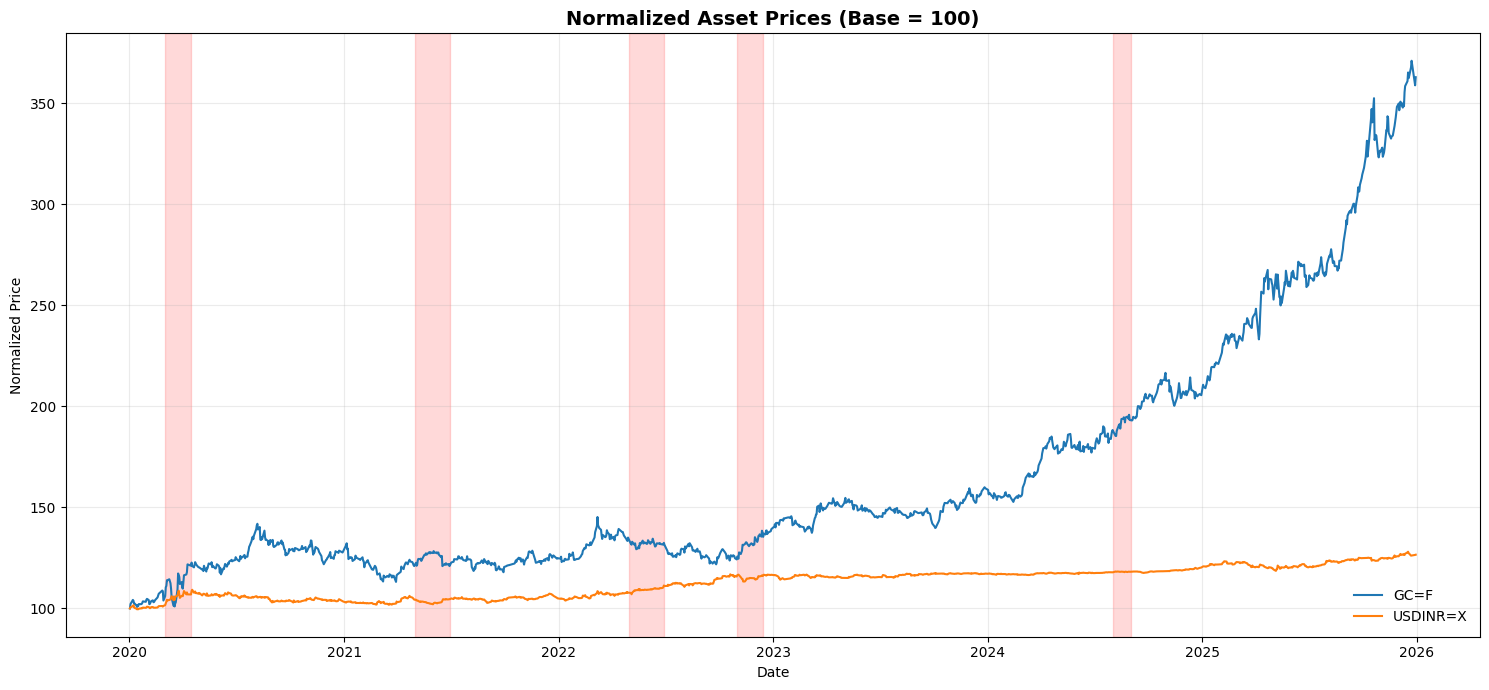

In [43]:
plot_normalized_prices(batch_size=2)

### DCC GARCH